In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
nav = pd.read_csv("../processed/02_nav_history_clean.csv")
perf = pd.read_csv("../processed/07_scheme_performance_clean.csv")
txn = pd.read_csv("../processed/08_investor_transactions_clean.csv")
holdings = pd.read_csv("../processed/09_portfolio_holdings_clean.csv")

nav["date"] = pd.to_datetime(nav["date"])
txn["transaction_date"] = pd.to_datetime(txn["transaction_date"])

print("NAV:", nav.shape)
print("Performance:", perf.shape)
print("Transactions:", txn.shape)
print("Holdings:", holdings.shape)

FileNotFoundError: [Errno 2] No such file or directory: '../processed/02_nav_history_clean.csv'

In [7]:
import os

print(os.getcwd())

c:\Users\hp\Desktop\Mutual_fund_Analysis\notebooks


In [8]:
import os

for root, dirs, files in os.walk("."):
    for file in files:
        if "02_nav" in file:
            print(os.path.join(root, file))

In [9]:
import os

print(os.listdir(".."))

['.git', 'amfi_validation.py', 'bluestock_mf.db', 'charts', 'check_columns.py', 'clean_data.py', 'create_db.py', 'dashboard', 'data', 'data_ingestion.py', 'fund_master_exploration.py', 'live_nav_fetch.py', 'load_data.py', 'notebooks', 'queries_test.py', 'README.md', 'reports', 'requirements.txt', 'show_columns.py', 'sql']


In [10]:
import os

print(os.listdir("../data"))

['processed', 'raw']


In [11]:
nav = pd.read_csv("../data/02_nav_history_clean.csv")
perf = pd.read_csv("../data/07_scheme_performance_clean.csv")
txn = pd.read_csv("../data/08_investor_transactions_clean.csv")
holdings = pd.read_csv("../data/09_portfolio_holdings_clean.csv")

FileNotFoundError: [Errno 2] No such file or directory: '../data/02_nav_history_clean.csv'

In [12]:
print(os.listdir(".."))
print(os.listdir("../data"))

['.git', 'amfi_validation.py', 'bluestock_mf.db', 'charts', 'check_columns.py', 'clean_data.py', 'create_db.py', 'dashboard', 'data', 'data_ingestion.py', 'fund_master_exploration.py', 'live_nav_fetch.py', 'load_data.py', 'notebooks', 'queries_test.py', 'README.md', 'reports', 'requirements.txt', 'show_columns.py', 'sql']
['processed', 'raw']


In [13]:
nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")
perf = pd.read_csv("../data/processed/07_scheme_performance_clean.csv")
txn = pd.read_csv("../data/processed/08_investor_transactions_clean.csv")
holdings = pd.read_csv("../data/processed/09_portfolio_holdings_clean.csv")

In [14]:
print(nav.shape)
print(perf.shape)
print(txn.shape)
print(holdings.shape)

(46000, 3)
(40, 19)
(32778, 13)
(322, 8)


In [15]:
nav["date"] = pd.to_datetime(nav["date"])
txn["transaction_date"] = pd.to_datetime(txn["transaction_date"])

print("Data Loaded Successfully")

Data Loaded Successfully


In [16]:
nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [17]:
results = []

for fund, grp in nav.groupby("amfi_code"):

    returns = grp["daily_return"].dropna()

    if len(returns) < 30:
        continue

    var95 = np.percentile(returns, 5)

    cvar95 = returns[
        returns <= var95
    ].mean()

    results.append([
        fund,
        var95,
        cvar95
    ])

var_cvar = pd.DataFrame(
    results,
    columns=[
        "amfi_code",
        "VaR_95",
        "CVaR_95"
    ]
)

var_cvar.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [18]:
var_cvar.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

print("var_cvar_report.csv saved successfully")

var_cvar_report.csv saved successfully


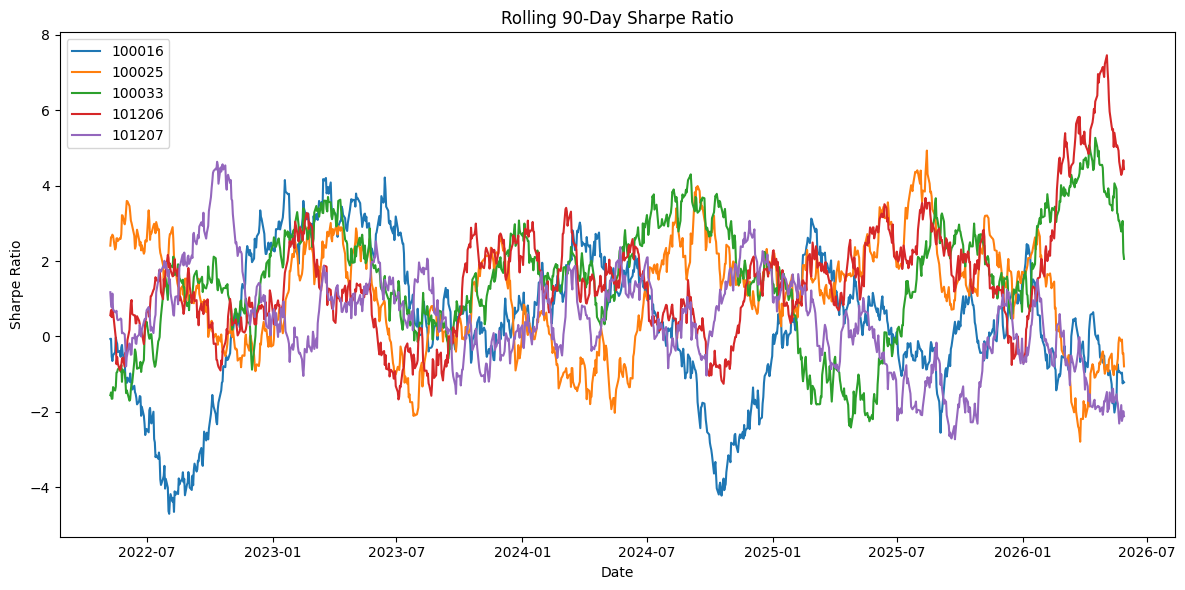

In [24]:
key_funds = nav["amfi_code"].unique()[:5]

plt.figure(figsize=(12,6))

for fund in key_funds:

    temp = nav[
        nav["amfi_code"] == fund
    ].copy()

    temp["rolling_sharpe"] = (
        temp["daily_return"]
        .rolling(90)
        .mean()
        /
        temp["daily_return"]
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    plt.plot(
        temp["date"],
        temp["rolling_sharpe"],
        label=str(fund)
    )

plt.legend()
plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")

plt.tight_layout()
plt.savefig("../charts/rolling_sharpe_chart.png")

plt.show()

In [20]:
first_txn = (
    txn.groupby("investor_id")
       ["transaction_date"]
       .min()
       .reset_index()
)

first_txn["cohort_year"] = (
    first_txn["transaction_date"]
    .dt.year
)

txn = txn.merge(
    first_txn[
        ["investor_id", "cohort_year"]
    ],
    on="investor_id"
)

cohort_analysis = (
    txn.groupby("cohort_year")
       .agg(
           avg_sip_amount=(
               "amount_inr",
               "mean"
           ),
           total_invested=(
               "amount_inr",
               "sum"
           )
       )
       .reset_index()
)

cohort_analysis

,cohort_year,avg_sip_amount,total_invested
0,2024,107422.541832,3491125187
1,2025,109158.577061,30455243


In [21]:
top_funds = (
    txn.groupby(
        ["cohort_year", "amfi_code"]
    )
    .size()
    .reset_index(name="count")
)

top_funds = (
    top_funds.sort_values(
        ["cohort_year", "count"],
        ascending=[True, False]
    )
    .groupby("cohort_year")
    .first()
)

top_funds

,amfi_code,count
cohort_year,,
2024,148568,874
2025,119599,12


In [22]:
sip = txn[
    txn["transaction_type"]
    .str.contains(
        "SIP",
        case=False,
        na=False
    )
].copy()

sip = sip.sort_values(
    ["investor_id", "transaction_date"]
)

sip["gap_days"] = (
    sip.groupby("investor_id")
       ["transaction_date"]
       .diff()
       .dt.days
)

sip_summary = (
    sip.groupby("investor_id")
       .agg(
           sip_count=(
               "transaction_date",
               "count"
           ),
           avg_gap_days=(
               "gap_days",
               "mean"
           )
       )
)

at_risk = sip_summary[
    (sip_summary["sip_count"] >= 6)
    &
    (sip_summary["avg_gap_days"] > 35)
]

print("At Risk Investors:")
print(len(at_risk))

At Risk Investors:
1332


In [23]:
holdings["weight_sq"] = (
    holdings["weight_pct"] / 100
) ** 2

hhi = (
    holdings.groupby("amfi_code")
    ["weight_sq"]
    .sum()
    .reset_index()
)

hhi.columns = [
    "amfi_code",
    "HHI"
]

hhi = hhi.sort_values(
    "HHI",
    ascending=False
)

hhi.head(10)

,amfi_code,HHI
11,119092,0.206448
3,101207,0.200700
18,119599,0.174751
4,102885,0.174709
7,118632,0.168298
29,148568,0.167930
21,120505,0.157570
22,120506,0.153794
27,125498,0.152414
23,120841,0.149680


# Advanced Insights

## Insight 1
Historical VaR analysis identified funds with the highest downside risk and return volatility.

## Insight 2
CVaR analysis showed the average loss beyond the VaR threshold, highlighting tail-risk exposure.

## Insight 3
Investor cohort analysis revealed that newer cohorts contributed the highest total investment amount.

## Insight 4
SIP continuity analysis identified investors with average SIP gaps greater than 35 days as at-risk investors.

## Insight 5
HHI concentration analysis showed that some funds maintain concentrated portfolios, increasing sector-specific risk.